In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [4]:
df = pd.read_csv('50_startups_dataset.csv')
print(df.head())

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    Pakistan  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54    Istanbul  191050.39
3  144372.41       118671.85        383199.62    Pakistan  182901.99
4  142107.34        91391.77        366168.42    Istanbul  166187.94


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [8]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [10]:
#  Check the shape of dataset
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (50, 5)
Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


In [11]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [12]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: >

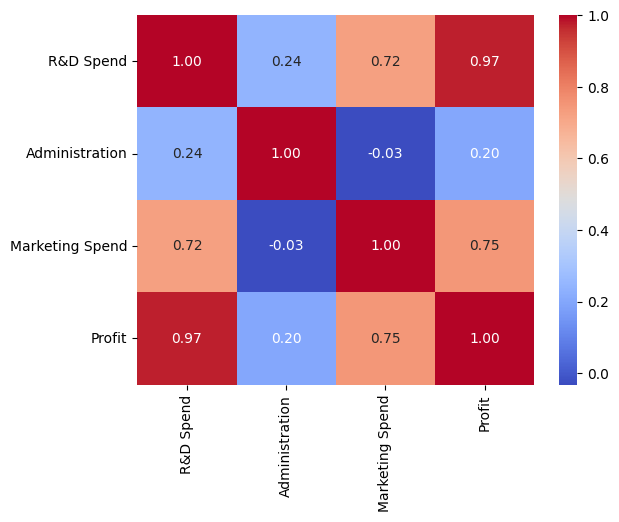

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

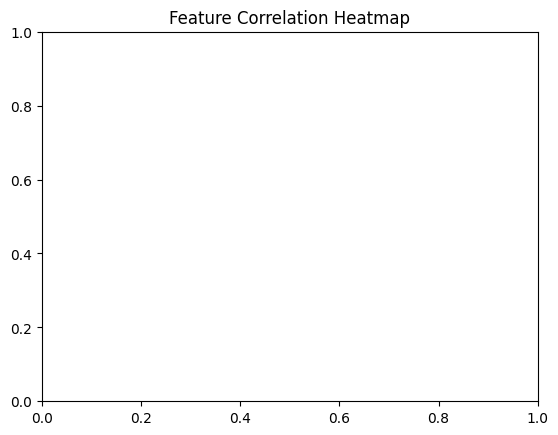

In [14]:
plt.title('Feature Correlation Heatmap')

In [15]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [16]:
plt.show()

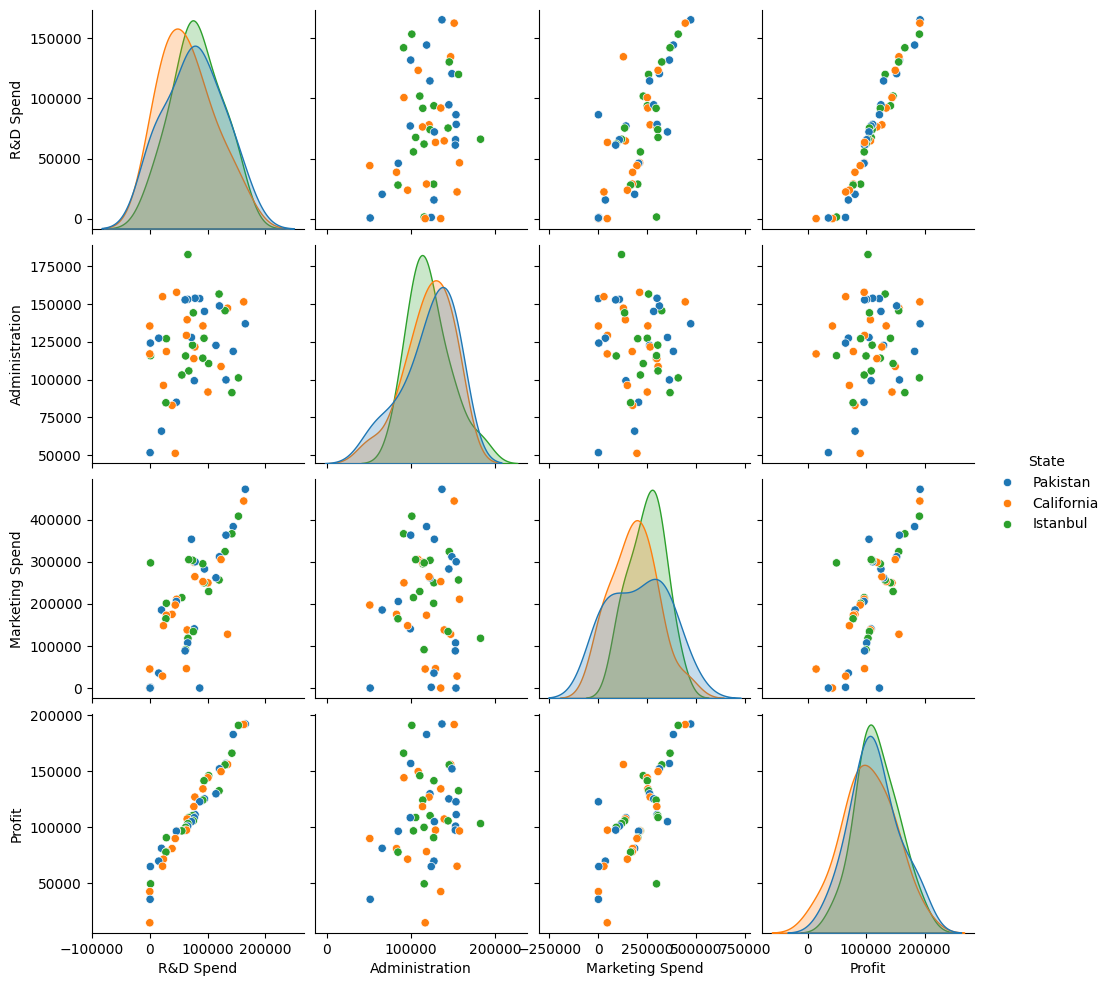

In [17]:
sns.pairplot(df, hue='State', diag_kind='kde')

In [18]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='Profit', ylabel='Count'>

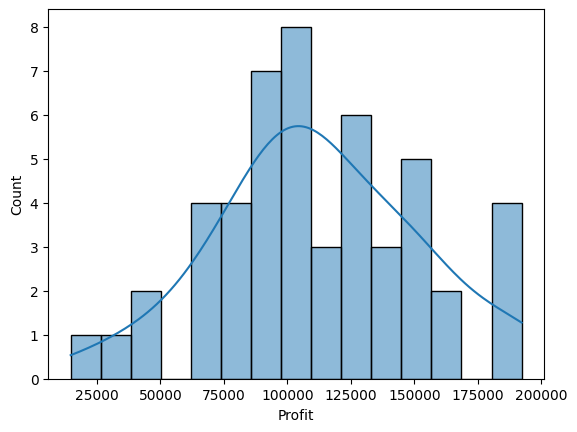

In [19]:
sns.histplot(df['Profit'], kde=True, bins=15)

Text(0.5, 1.0, 'Distribution of Startup Profit')

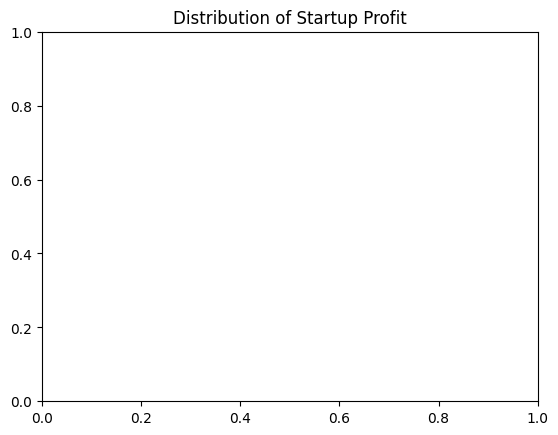

In [20]:
plt.title('Distribution of Startup Profit')

In [21]:
plt.show()

In [22]:
df['State'].value_counts()

State
Pakistan      17
California    17
Istanbul      16
Name: count, dtype: int64

In [23]:
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

In [24]:
df_encoded.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Istanbul,State_Pakistan
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [25]:
X = df_encoded.drop('Profit', axis=1)

In [26]:
y = df_encoded['Profit']

In [27]:
print(f"Features shape: {X.shape}")

Features shape: (50, 5)


In [28]:
print(f"Target shape: {y.shape}")

Target shape: (50,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
print(f"Training set: {X_train.shape[0]} samples")

Training set: 40 samples


In [31]:
print(f"Test set:     {X_test.shape[0]} samples")

Test set:     10 samples


In [32]:
model = LinearRegression()

In [33]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [35]:
print(f"Intercept: {model.intercept_:.2f}")

Intercept: 54028.04


In [36]:
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:25s} -> {coef:>12.2f}")


Feature Coefficients:
  R&D Spend                 ->         0.81
  Administration            ->        -0.07
  Marketing Spend           ->         0.03
  State_Istanbul            ->       938.79
  State_Pakistan            ->         6.99


In [37]:
y_pred = model.predict(X_test)

In [38]:
comparison = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': y_pred,
    'Difference': y_test.values - y_pred
})

In [39]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 40)
print("  MODEL EVALUATION METRICS")
print("=" * 40)
print(f"  R2 Score : {r2:.4f}")
print(f"  MAE      : ${mae:,.2f}")
print(f"  MSE      : ${mse:,.2f}")
print(f"  RMSE     : ${rmse:,.2f}")
print("=" * 40)

  MODEL EVALUATION METRICS
  R2 Score : 0.8987
  MAE      : $6,961.48
  MSE      : $82,010,363.04
  RMSE     : $9,055.96


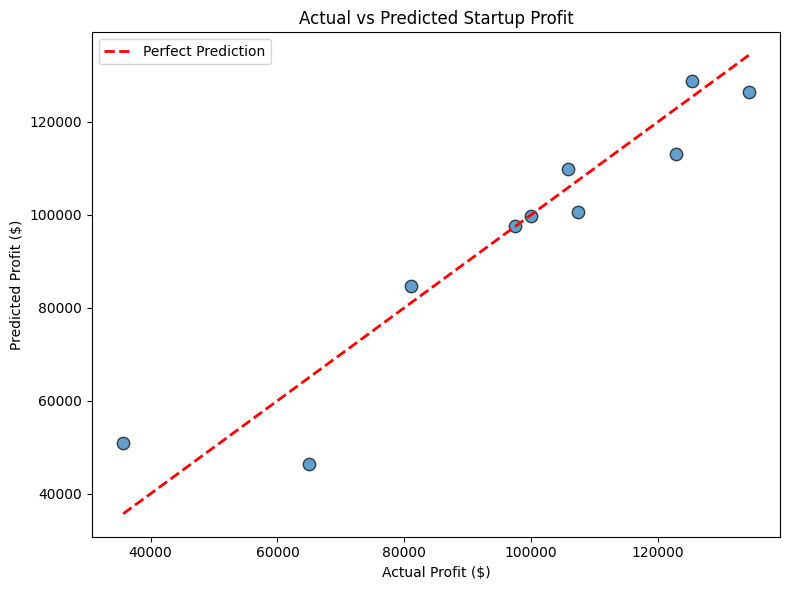

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', s=80)
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Profit ($)')
plt.ylabel('Predicted Profit ($)')
plt.title('Actual vs Predicted Startup Profit')
plt.legend()
plt.tight_layout()
plt.show()

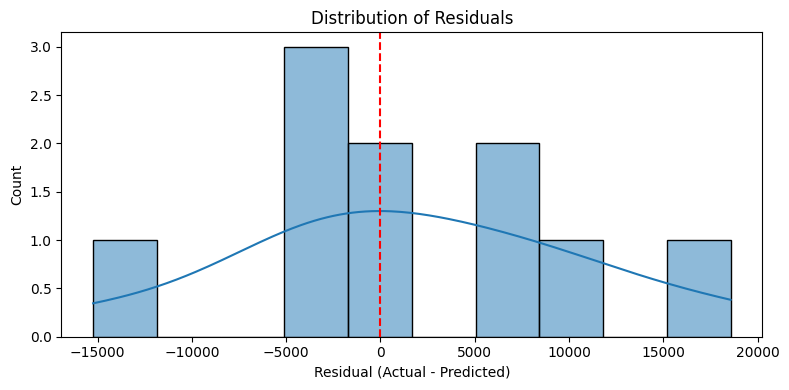

In [41]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=10)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

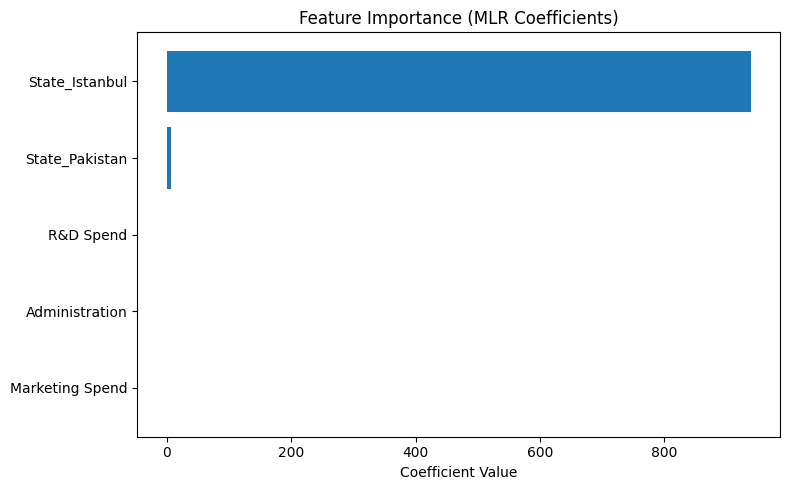

In [42]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (MLR Coefficients)')
plt.tight_layout()
plt.show()

In [51]:
import warnings
warnings.filterwarnings('ignore')

new_startup = pd.DataFrame({
    'R&D Spend': [160000],
    'Administration': [130000],
    'Marketing Spend': [300000],
    'State_Istanbul': [1],
    'State_Pakistan': [0]
})

In [52]:
predicted_profit = model.predict(new_startup)

In [53]:
print(f"Predicted Profit for new startup: ${predicted_profit[0]:,.2f}")

Predicted Profit for new startup: $183,881.85
